In [20]:

import os
import sys
import random
from pathlib import Path
from importlib import reload

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score



# Seeds
SEED = 58
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# # Add parent directory to path for imports (notebook context doesn't have __file__)

print("Current working dir:", Path().resolve())

LOCAL_ROOT = Path().resolve()
SRC_PATH = LOCAL_ROOT / "src"

if not SRC_PATH.exists():
    LOCAL_ROOT = Path().resolve().parent
    SRC_PATH = LOCAL_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("LOCAL_ROOT:", LOCAL_ROOT)
print("SRC_PATH:", SRC_PATH)
print("SRC exists:", SRC_PATH.exists())

# Reload safety (clear cached modules)
for mod in list(sys.modules.keys()):
    if "base" in mod or "data_loader" in mod or "ModelWrapper" in mod or "benchmark" in mod:
        del sys.modules[mod]

# Auto-configure paths from centralized config
from benchmark_config import (
    PROJECT_ROOT, SRC_ROOT, ADBENCH_ROOT, ADBENCH_DATASETS,
    DATASET_CONFIG, TEST_SCENARIOS, EVAL_DATASETS,
    get_scenario, get_model_config
)

# Ensure paths are in sys.path
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
if str(ADBENCH_ROOT) not in sys.path:
    sys.path.append(str(ADBENCH_ROOT))

from utils import create_models, validate_data

import base
base = reload(base)
from base import Model, Data, CoLearning
from colearner import SimpleCoLearner, SingleModel, CoLearnerVal
from strategy import SimpleStrategy, PlateauStrategy, AdaptivePlateauStrategy, RecurrentPlateauStrategy
import baselines.adbench.ModelWrapperADBench as mw
mw = reload(mw)
from baselines.adbench.ModelWrapperADBench import PYOD_AVAILABLE
from baselines.adbench.data_loader import ClassicalADBenchData, load_data

# Data loading configuration
TRAIN_SPLIT = 0.60
VAL_TEST_SPLIT = 0.50
SEMI_LABEL_RATIO = 0.10
SEMI_STRATIFIED = True
PRESERVE_LABELED = True

print(f"Paths: root={PROJECT_ROOT.name}, data={ADBENCH_DATASETS}")
print(f"Config: train={TRAIN_SPLIT} val_test={VAL_TEST_SPLIT} semi={SEMI_LABEL_RATIO} strat={SEMI_STRATIFIED} preserve={PRESERVE_LABELED}")

Current working dir: /home/m-adam/rough_new/CLADBench_02_rough/src
LOCAL_ROOT: /home/m-adam/rough_new/CLADBench_02_rough
SRC_PATH: /home/m-adam/rough_new/CLADBench_02_rough/src
SRC exists: True
Paths: root=CLADBench_02_rough, data=/home/m-adam/rough_new/CLADBench_02_rough/SubModules/ADBench/adbench/datasets/Classical
Config: train=0.6 val_test=0.5 semi=0.1 strat=True preserve=True


In [21]:
%matplotlib inline
from IPython.display import display
import matplotlib
print(matplotlib.get_backend())

inline


In [22]:
import sys, torch, sklearn, numpy
import importlib.metadata as md

print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("NumPy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("pyod:", md.version("pyod"))

print("\n✅ Environment loaded. Version checks are informational only on SSH GPU server.")

Python: 3.11.14
Torch: 2.12.0.dev20260407+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
NumPy: 1.26.4
scikit-learn: 1.8.0
pyod: 3.2.1

✅ Environment loaded. Version checks are informational only on SSH GPU server.


In [23]:
# Use centralized path configuration
# DATASET_PATH = DATASET_CONFIG["path"]                                       
DATASET_PATH = ADBENCH_DATASETS / "47_yeast.npz"     #    2_annthyroid.npz 5_campaign.npz 7_Cardiotocography.npz 17_InternetAds.npz 27_PageBlocks.npz 47_yeast.npz 32_shuttle.npz   4_breastw.npz 20news_0.npz  CIFAR10_0.npz   1_ALOI.npz  
# DATASET_PATH = ADBENCH_ROOT / "adbench" / "datasets" / "NLP_by_BERT" / "yelp.npz"
print("Using dataset:", DATASET_PATH.name) 

data = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED,
    random_state=SEED)

# Benchmark integrity checks
validate_data(data)

labels = data.semisupervised_labels
n_real = int(np.sum(labels != -1))
n_false = int(np.sum(labels == -1))

print(f"Data: train={data.n_train} val={data.n_val} test={data.n_test} d={data.X_train.shape[1]} at {DATASET_PATH}")
print(f"original labels: among {data.n_train} really labeled ={int(np.sum(labels!=-1))} unlabeled (-1) = {int(np.sum(labels==-1))}")
print(f"unlabeled_policy: {data.unlabeled_policy}")

Using dataset: 47_yeast.npz
Data: train=890 val=297 test=297 d=8 at /home/m-adam/rough_new/CLADBench_02_rough/SubModules/ADBench/adbench/datasets/Classical/47_yeast.npz
original labels: among 890 really labeled =89 unlabeled (-1) = 801
unlabeled_policy: unlabeled_as_normal


In [24]:
model_to_test = "prenet"                             # still using prenet as tester as deepsad will be less useful for debugging the collaborative/TExGAD behavior as it is unsupervised and is less effected by p-lables
model_names = ["deepsad", "prenet", "devnet"]
recurrent_model = ["gru"]                            # TODO flexible way of changing the recurrent model

In [25]:
#TEST 1 : solo model train, quick check to see if it learns, if the loss (if available) gets minimized
#TODO, iterate on the models in model_names instead of only moddel_to_test 
registry = mw.get_model_detector_dict()
results_summary = {}

prenet_cls = registry[model_to_test]
print(f"Model: {prenet_cls.__name__}")

train_config = {"total_epochs": 2, "batch_size": 256}
prenet = prenet_cls(train_config=train_config, model_config={}, data=data)

for epoch in range(5):
    prenet.train(1)
    scores = prenet.predict_scores()
    auc_score = roc_auc_score(data.y_test, scores)
    loss = None
    if hasattr(prenet, "get_loss"):
        try:
            loss = prenet.get_loss()
        except TypeError:
            loss = None
    loss_str = f" loss={loss:.4f}" if loss is not None else ""
    print(f"epoch {epoch} auc={auc_score:.4f}{loss_str}")

results_summary[model_to_test] = auc_score
print(f"Summary: {model_to_test} auc={auc_score:.4f}")

Model: PReNetWrapper
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
epoch 0 auc=0.4476 loss=0.9916
epoch 1 auc=0.4618 loss=0.9904
epoch 2 auc=0.4729 loss=0.9891
epoch 3 auc=0.4813 loss=0.9879
epoch 4 auc=0.4867 loss=0.9866
Summary: prenet auc=0.4867


In [26]:
#TEST 2 : check if co-learning and its strategy work, 
registry = mw.get_model_detector_dict()
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TERM"] = "dumb"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.keras.utils.disable_interactive_logging()

from colearner import BasicAdaptiveCoLearner
CoLearnerClass = BasicAdaptiveCoLearner

data_test1 = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED,
    random_state=SEED,
)

print(f"TEST1 solo vs {CoLearnerClass.__name__}: {model_names}")

models = create_models(registry, model_names, data_test1)
solo_results = {}

for i, model in enumerate(models):
    model.fit()
    scores = model.predict_scores()
    auc = roc_auc_score(data_test1.y_test, scores)
    solo_results[f"model_{i}"] = auc

print("Solo AUCs: " + ", ".join([f"{k}={v:.4f}" for k, v in solo_results.items()]))

strategy = PlateauStrategy(metric_key="ensemble", mode="max", patience=5, min_delta=0.001)

CV_LOW_TH          = 0.05
CV_HIGH_TH         = 0.90
CV_PURIFY_ANOMALY  = 0.60
CV_PURIFY_NORMAL   = 0.20

colearner = CoLearnerClass(
    models=models,
    data=data_test1,
    strategy=strategy,
    warmup_epochs=1,
    max_chapters=3,
    anomaly_threshold=0.5,
    confidence_threshold_low=CV_LOW_TH,
    confidence_threshold_high=CV_HIGH_TH,
    purification_ratio_anomaly=CV_PURIFY_ANOMALY,
    purification_ratio_normal=CV_PURIFY_NORMAL,
    )
history = colearner.cotrain(eval_interval=1)
colearner.exchange_history[-1]

# ADD THESE 2 LINES:
for ch_idx, stats in enumerate(colearner.exchange_history):
    print(f"Ch {ch_idx}: anom={stats['n_anomalies']}, norm={stats['n_normals']}")
collab_metrics = {}
for i, model in enumerate(models):
    test_scores = model.predict_scores()
    collab_metrics[f"model_{i}"] = roc_auc_score(data_test1.y_test, test_scores)
# ensemble_scores = np.mean([model.predict_scores() for model in models], axis=0)
ensemble_scores = colearner._adaptive_ensemble_scores([model.predict_scores() for model in models])
collab_metrics["ensemble"] = roc_auc_score(data_test1.y_test, ensemble_scores)

for key, value in collab_metrics.items():
    solo_val = solo_results.get(key, 0.0)
    delta = value - solo_val
    print(f"{key}: solo={solo_val:.4f} collab={value:.4f} delta={delta:+.4f}")
    print(
    f"Ch {ch_idx + 1}: anom={stats.get('n_anomalies', 0)}, "
    f"norm={stats.get('n_normals', 0)}, "
    f"TP={stats.get('tp', 0)}, FP={stats.get('fp', 0)}, "
    f"TN={stats.get('tn', 0)}, FN={stats.get('fn', 0)}"
)

TEST1 solo vs BasicAdaptiveCoLearner: ['deepsad', 'prenet', 'devnet']
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
Solo AUCs: model_0=0.5374, model_1=0.5702, model_2=0.5574
Ch 0: anom=2, norm=90
Ch 1: anom=0, norm=64
Ch 2: anom=6, norm=28
model_0: solo=0.5374 collab=0.5358 delta=-0.0016
Ch 3: anom=6, norm=28, TP=0, FP=6, TN=16, FN=12
model_1: solo=0.5702 collab=0.5739 delta=+0.0037
Ch 3: anom=6, norm=28, TP=0, FP=6, TN=16, FN=12
model_2: solo=0.5574 collab=0.5574 delta=+0.0000
Ch 3: anom=6, norm=28, TP=0, FP=6, TN=16, FN=12
ensemble: solo=0.0000 collab=0.5456 delta=+0.5456
Ch 3: anom=6, norm=28, TP=0, FP=6, TN=16, FN=12


DeepSAD (UD) is sending high-confidence normal/anomaly labels to both PReNet (SD) and DevNet (DD) respectively , while PReNet also sends learned anomaly patterns to both DevNet and DeepSAD.

DevNet (DD) receives from both DeepSAD and PReNet (so it improves most), and also sends back refined signals to them, which is why its AUC increases the most.


In [27]:
print("TEST3 pseudo-labels")
labels_test1 = data_test1.semisupervised_labels
print(f"original labels: among {data_test1.n_train} | anomalies = {int(np.sum(labels_test1==1))} | normals = {int(np.sum(labels_test1==0))} | unlabeled (-1) = {int(np.sum(labels_test1==-1))}")

for model_idx, model in enumerate(models):
    pseudo_labels = model._pseudo_labels
    n_pseudo = np.sum(pseudo_labels != -1)
    n_normal = np.sum(pseudo_labels == 0)
    n_anomaly = np.sum(pseudo_labels == 1)
    print(f"{model.__class__.__name__}: total={n_pseudo} normal={n_normal} anomaly={n_anomaly} | proportion = {round(100*n_pseudo/int(np.sum(labels_test1==-1)),4)}%")

TEST3 pseudo-labels
original labels: among 890 | anomalies = 30 | normals = 59 | unlabeled (-1) = 801
DeepSADWrapper: total=17 normal=14 anomaly=3 | proportion = 2.1223%
PReNetWrapper: total=14 normal=14 anomaly=0 | proportion = 1.7478%
DevNetWrapper: total=3 normal=0 anomaly=3 | proportion = 0.3745%


In [ ]:
# GRU Recurrent Ensemble Test
from importlib import reload
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TERM"] = "dumb"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.keras.utils.disable_interactive_logging()
import colearner as colearner_mod
import recurrentmodels as recurrentmodels_mod
colearner_mod = reload(colearner_mod)
recurrentmodels_mod = reload(recurrentmodels_mod)
from colearner import DelayedRecurrentBasicAdaptiveCoLearner
from recurrentmodels import GRURecurrentModel, LSTMRecurrentModel, SlidingWindowLSTMRecurrentModel, PermInvariantModel
from strategy import RecurrentPlateauStrategy
from utils import extract_embeddings_auto

registry = mw.get_model_detector_dict()

model_names_gru = ["deepsad", "prenet", "devnet"]
data_gru = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED,
    random_state=SEED,
 )

models_gru = create_models(registry, model_names_gru, data_gru)
# gru_model = GRURecurrentModel(
#     hidden_size=128,
#     num_layers=1,
#     dropout=0.0,
#     lr=1e-3,
#     batch_size=256,
#     num_epochs=5,
#     seed=SEED,
#     n_detectors=len(models_gru),
#  )
# gru_model = SlidingWindowLSTMRecurrentModel(
#     hidden_size=128,
#     num_layers=1,
#     dropout=0.0,
#     lr=1e-3,
#     batch_size=256,
#     num_epochs=5,
#     seed=SEED,
#     n_detectors=9,
#     window_size=6,
#     stride=3,
# )

gru_model = PermInvariantModel(
    hidden_size=128,
    dropout=0.0,
    lr=1e-3,
    batch_size=256,
    num_epochs=5,
    seed=SEED,
    n_detectors=len(models_gru),
    pool="attention",
) 
  
CV_LOW_TH          = 0.05
CV_HIGH_TH         = 0.90
CV_PURIFY_ANOMALY  = 0.60
CV_PURIFY_NORMAL   = 0.20

# GRU-aware strategy: monitors detector ensemble before GRU starts,
# then switches to monitoring GRU AUC once the judge model is active
strategy_gru = RecurrentPlateauStrategy(
    #recurrent_start_chapter=3,
    recurrent_start_chapter=3,
    fallback_key="ensemble",
    recurrent_key="gru",
    mode="max",
    patience_fallback=5,   
    patience_recurrent=5,  
    min_delta=0.001,      
)

colearner_gru = DelayedRecurrentBasicAdaptiveCoLearner(
    models=models_gru,
    data=data_gru,
    strategy=strategy_gru,
    recurrent_model=gru_model,
    warmup_epochs=10,
    max_chapters=15,
    epochs_per_chapter=4,
    embeddings_aggregate="stack",
    recurrent_start_chapter=3,
    adaptive_start_window=3,
    adaptive_start_tolerance=0.003,
    adaptive_max_wait_chapter=12,                                          # should be less than max_chapters=15,
    anomaly_threshold=0.5,
    confidence_threshold_low=CV_LOW_TH,
    confidence_threshold_high=CV_HIGH_TH,
    purification_ratio_anomaly=CV_PURIFY_ANOMALY,
    purification_ratio_normal=CV_PURIFY_NORMAL,
    recurrent_include_raw=True,
    recurrent_include_scores=True,
    specialist_forgetting=False,
    recurrent_token_sequence=False,
    gate_enabled=True,                                                    # NEW
    gate_target_precision_anomaly=0.60,
    gate_target_precision_normal=0.90,
    gate_precision_margin=0.05,
    gate_min_support=10,
    )

# Val loss is now computed automatically by the colearner with fresh embeddings
history_gru = colearner_gru.cotrain(eval_interval=1)

for ch_idx, stats in enumerate(colearner_gru.exchange_history):
    print(
        f"Ch {ch_idx + 1}: anom={stats.get('n_anomalies', 0)}, "
        f"norm={stats.get('n_normals', 0)}, "
        f"TP={stats.get('tp', 0)}, FP={stats.get('fp', 0)}, "
        f"TN={stats.get('tn', 0)}, FN={stats.get('fn', 0)}"
    )

# ADD THESE before the monkey-patch
print(f"GRU fitted: {gru_model._fitted}")
print(f"GRU train loss history: {gru_model._train_loss_history}")

colearner_gru.embeddings_use_train = False
test_embeddings = colearner_gru._collect_embeddings(indexes=None)
gru_scores = gru_model.predict_scores(test_embeddings)
gru_auc = roc_auc_score(data_gru.y_test, gru_scores)
print(f"GRU Recurrent Model Test AUC on {DATASET_PATH.stem}: {gru_auc:.4f}")


number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on


TypeError: SimpleCoLearner.__init__() got an unexpected keyword argument 'anomaly_replay'

In [ ]:
# NEW TEST

print("Ch | anom_n  anom_prec | norm_n  norm_prec | total")
print("-" * 56)
for ch, s in enumerate(colearner_gru.exchange_history):
    tp, fp, tn, fn = s.get("tp", 0), s.get("fp", 0), s.get("tn", 0), s.get("fn", 0)
    anom_n = tp + fp
    norm_n = tn + fn
    ap = tp / max(1, anom_n)
    np_ = tn / max(1, norm_n)
    print(f"{ch+1:>2} | {anom_n:>5}  {ap:>8.3f} | {norm_n:>5}  {np_:>8.3f} | {anom_n+norm_n}")

Ch | anom_n  anom_prec | norm_n  norm_prec | total
--------------------------------------------------------
 1 |     0     0.000 |    72     0.667 | 72
 2 |     0     0.000 |    96     0.688 | 96
 3 |     0     0.000 |    62     0.742 | 62
 4 |     0     0.000 |    24     0.667 | 24
 5 |     0     0.000 |    36     0.833 | 36
 6 |     0     0.000 |    36     0.889 | 36
 7 |     0     0.000 |    12     0.667 | 12
 8 |     0     0.000 |     6     1.000 | 6
 9 |     0     0.000 |    28     0.500 | 28
10 |     0     0.000 |    34     0.588 | 34
11 |     0     0.000 |    46     0.609 | 46
12 |     0     0.000 |    48     0.583 | 48
13 |     0     0.000 |     8     0.750 | 8
14 |     0     0.000 |    10     0.600 | 10
15 |     0     0.000 |    46     0.565 | 46


In [ ]:
print("Ch | gru_train_loss | gru_val_loss | gru_val_auc | ensemble_val_auc")
print("-" * 70)
chapters = history_gru["chapters"]
tl = gru_model._train_loss_history
vl = gru_model._val_loss_history
for i, ch in enumerate(chapters):
    t = f"{tl[i]:.4f}" if i < len(tl) else "  —"
    v = f"{vl[i]:.4f}" if i < len(vl) else "  —"
    g = f"{ch.get('gru', float('nan')):.4f}"
    e = f"{ch.get('ensemble', float('nan')):.4f}"
    print(f"{i+1:>2} | {t:>13} | {v:>11} | {g:>10} | {e:>15}")

Ch | gru_train_loss | gru_val_loss | gru_val_auc | ensemble_val_auc
----------------------------------------------------------------------
 1 |        0.7181 |      0.6893 |        nan |          0.5606
 2 |        0.7158 |      0.6928 |        nan |          0.5395
 3 |        0.7140 |      0.6959 |        nan |          0.5200
 4 |        0.7125 |      0.6986 |        nan |          0.5029
 5 |        0.7112 |      0.7007 |        nan |          0.4986
 6 |        0.6933 |      0.7015 |        nan |          0.4959
 7 |        0.6921 |      0.7017 |     0.5634 |          0.5030
 8 |        0.6908 |      0.7011 |     0.5701 |          0.5001
 9 |        0.6894 |      0.6999 |     0.5769 |          0.5086
10 |        0.6879 |      0.6984 |     0.5854 |          0.5155
11 |        0.7288 |      0.6980 |     0.5911 |          0.5160
12 |        0.7270 |      0.6978 |     0.5966 |          0.5422
13 |        0.7250 |      0.6982 |     0.6043 |          0.5617
14 |        0.7228 |      0.6

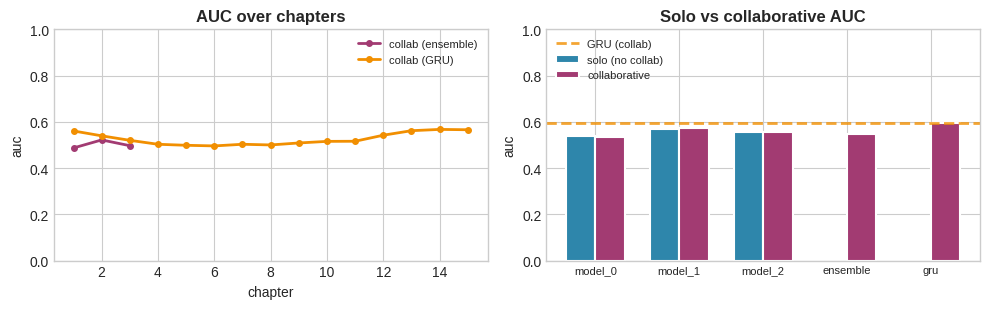

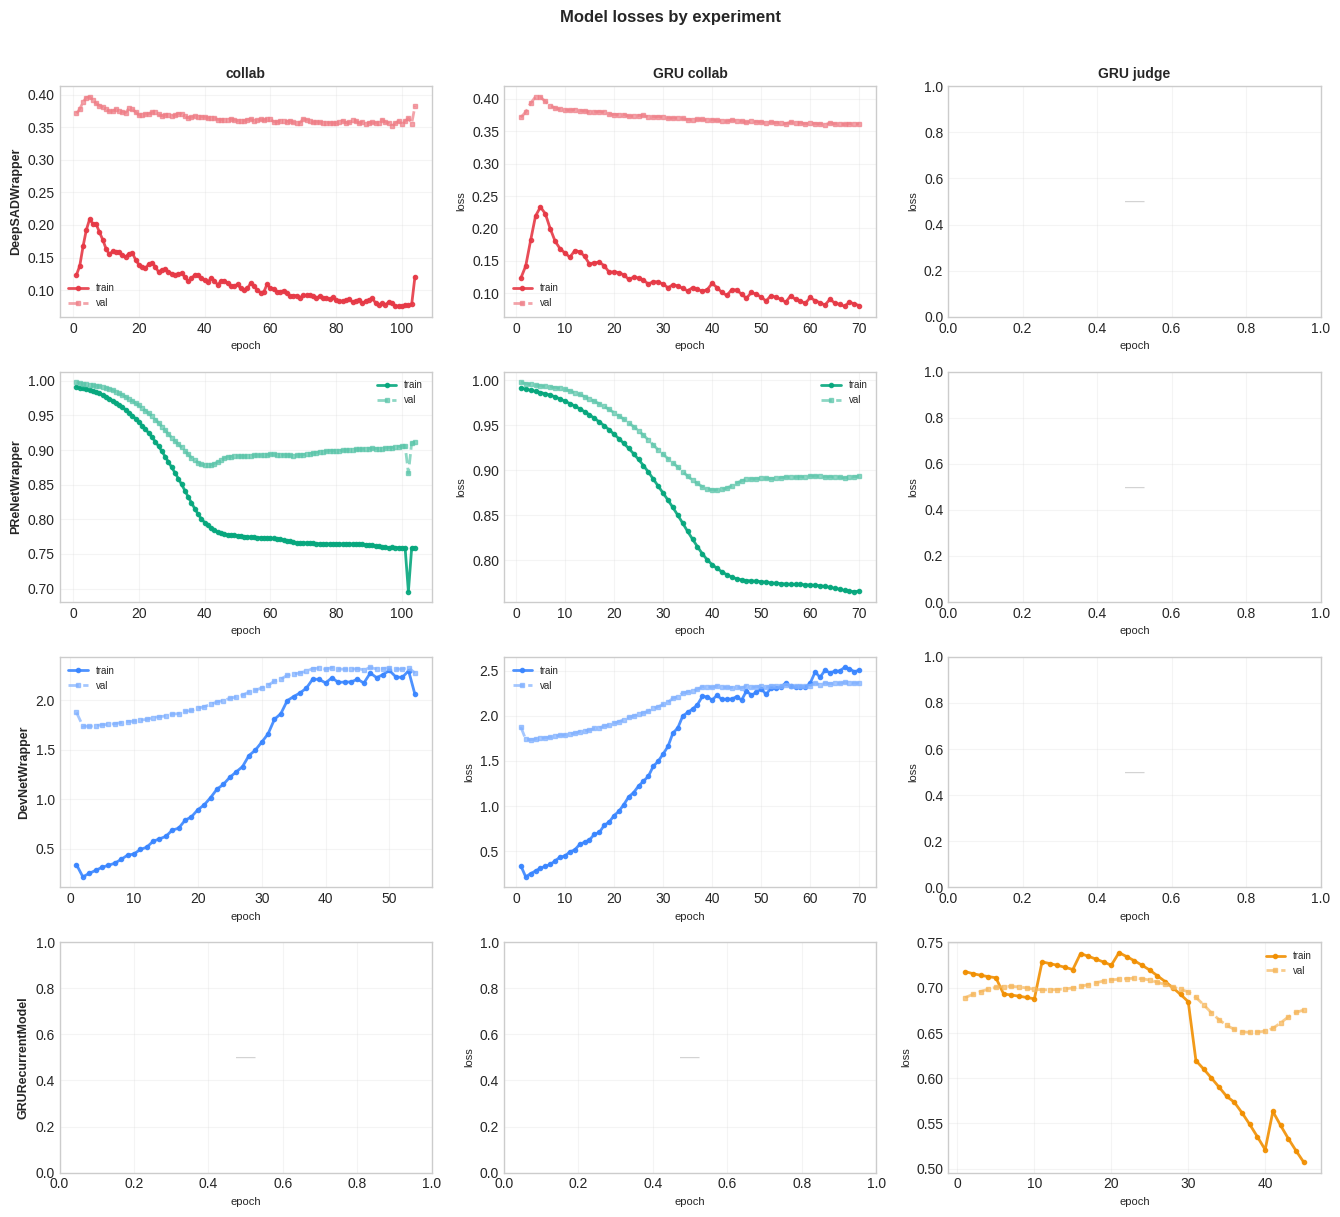

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict, OrderedDict
import matplotlib.pyplot as plt
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TERM"] = "dumb"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.keras.utils.disable_interactive_logging()

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "solo": "#2E86AB",
    "collab": "#A23B72",
    "gru": "#F18F01",
    "prenet": "#06A77D",
    "deepsad": "#E63946",
    "devnet": "#3A86FF",
    "ensemble": "#8338EC",
}

def _lighten_color(color, amount=0.35):
    """Lighten a color by mixing with white."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

def _plot_auc(histories, labels, ax, title):
    colors_map = ["#A23B72", "#F18F01"]
    for i, (hist, label) in enumerate(zip(histories, labels)):
        if not hist or "chapters" not in hist or not hist["chapters"]:
            continue
        chapters = hist["chapters"]
        x = np.arange(1, len(chapters) + 1)
        y = [c.get("ensemble", np.nan) for c in chapters]
        ax.plot(x, y, marker="o", linewidth=2, markersize=4, label=label, color=colors_map[i])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("chapter"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)

def _plot_solo_vs_collab(solo, collab, gru_val, ax, title):
    if not solo or not collab:
        return
    keys = [k for k in collab.keys() if k in solo]
    if "ensemble" in collab:
        keys.append("ensemble")
    labels = keys + (["gru"] if gru_val is not None else [])
    solo_vals = [solo.get(k, np.nan) for k in keys] + ([np.nan] if gru_val is not None else [])
    collab_vals = [collab.get(k, np.nan) for k in keys] + ([gru_val] if gru_val is not None else [])
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x - w/2, solo_vals, width=w, label="solo (no collab)", color=COLORS["solo"], edgecolor="white", linewidth=1.5)
    ax.bar(x + w/2, collab_vals, width=w, label="collaborative", color=COLORS["collab"], edgecolor="white", linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    if gru_val is not None and not np.isnan(gru_val):
        ax.axhline(y=gru_val, color=COLORS["gru"], linestyle="--", linewidth=2, label="GRU (collab)", alpha=0.8)
    ax.legend(fontsize=8, loc="best")

# ── AUC overview ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
_plot_auc([history, history_gru], ["collab (ensemble)", "collab (GRU)"], axes[0], "AUC over chapters")
_plot_solo_vs_collab(solo_results, collab_metrics, gru_auc if 'gru_auc' in globals() else None, axes[1], "Solo vs collaborative AUC")
fig.tight_layout()
display(fig)
plt.close(fig)

# ── Loss mosaic: rows = model type, cols = experiment ──
color_map = {
    "PReNetWrapper": COLORS["prenet"],
    "DeepSADWrapper": COLORS["deepsad"],
    "DevNetWrapper": COLORS["devnet"],
    "GRURecurrentModel": COLORS["gru"],
}
experiments = OrderedDict([
    ("solo", list(solo_models.values()) if 'solo_models' in globals() else []),
    ("collab", models if 'models' in globals() else []),
    ("GRU collab", models_gru if 'models_gru' in globals() else []),
])
# Build grid[model_type][experiment] = model
grid = OrderedDict()
for exp, ms in experiments.items():
    ms = ms if isinstance(ms, list) else [ms]
    for m in ms:
        name = m.__class__.__name__
        grid.setdefault(name, OrderedDict())[exp] = m
# Append GRU judge as its own row
grid["GRURecurrentModel"] = {"GRU judge": gru_model}

row_names = list(grid.keys())
col_set = []
for row_data in grid.values():
    for c in row_data:
        if c not in col_set:
            col_set.append(c)

nrows = len(row_names)
ncols = len(col_set)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows), squeeze=False)

for r, model_type in enumerate(row_names):
    row_data = grid[model_type]
    color = color_map.get(model_type, "#555555")
    for c, exp in enumerate(col_set):
        ax = axes[r][c]
        m = row_data.get(exp)
        has = False
        if m is not None:
            train = getattr(m, "_train_loss_history", None)
            val = getattr(m, "_val_loss_history", None)
            if train:
                ax.plot(np.arange(1, len(train)+1), train, marker="o", linewidth=2,
                        markersize=3, color=color, label="train", alpha=0.9)
                has = True
            if val:
                val_c = _lighten_color(color, 0.35)
                ax.plot(np.arange(1, len(val)+1), val, marker="s", linewidth=2,
                        markersize=3, color=val_c, linestyle="--", label="val", alpha=0.7)
                has = True
            if not has:
                last = getattr(m, "_last_loss", None)
                if last is not None:
                    ax.plot([1], [last], marker="o", markersize=6, color=color, label="last loss")
                    has = True
        if has:
            ax.legend(fontsize=7, loc="best")
        else:
            ax.text(0.5, 0.5, "—", ha="center", va="center", transform=ax.transAxes, fontsize=14, color="lightgray")
        ax.set_xlabel("epoch", fontsize=8); ax.set_ylabel("loss", fontsize=8)
        ax.grid(True, alpha=0.2)
        # Row / col headers
        if c == 0:
            ax.set_ylabel(model_type, fontsize=9, fontweight="bold")
        if r == 0:
            ax.set_title(exp, fontweight="bold", fontsize=10)

fig.suptitle("Model losses by experiment", fontweight="bold", fontsize=12, y=1.01)
fig.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
# NEW CODE BLOCK FOR AP ══════════════════════════════════════════════════════════════════════
# CROSS-VALIDATION BENCHMARK  –  N trials, different random seeds
# Evaluates: solo baselines · collaborative · adaptive GRU judge
# Stores: AUC, AP, loss histories, per-chapter AUCs, FP/FN pseudo-label stats
# ══════════════════════════════════════════════════════════════════════
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import time
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score, average_precision_score

tf.get_logger().setLevel("ERROR")
tf.keras.utils.disable_interactive_logging()

from colearner import BasicAdaptiveCoLearner, DelayedRecurrentBasicAdaptiveCoLearner
from recurrentmodels import GRURecurrentModel, LSTMRecurrentModel, SlidingWindowLSTMRecurrentModel, PermInvariantModel
from strategy import PlateauStrategy, RecurrentPlateauStrategy

N_TRIALS       = 3
CV_WARMUP      = 15
CV_MAX_CHAP    = 45
CV_EP_PER_CHAP = 4
CV_GRU_START   = 3

# Cleaner pseudo-label setting for AP
CV_LOW_TH          = 0.05
CV_HIGH_TH         = 0.90
CV_PURIFY_ANOMALY  = 0.60
CV_PURIFY_NORMAL   = 0.20

registry = mw.get_model_detector_dict()

cv_results = {
    "n_trials": N_TRIALS,
    "dataset": str(DATASET_PATH),
    "model_names": list(model_names),
    "seeds": [],

    "solo": {
        n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
        for n in model_names
    },

    "collab": {
        n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
        for n in list(model_names) + ["ensemble"]
    },

    "collab_chapters": [],
    "collab_val_loss": [],
    "collab_exchange_history": [],

    "gru": {
        "auc": [],
        "ap": [],
        "same_run_ensemble_auc": [],
        "same_run_ensemble_ap": [],
        "train_loss": [],
        "val_loss": [],
        "chapters": [],
    },

    "gru_exchange_history": [],
}

t_total = time.time()

for trial_idx in range(N_TRIALS):
    seed = SEED + trial_idx
    cv_results["seeds"].append(seed)

    t0 = time.time()
    print(f"\n{'─' * 60}\n Trial {trial_idx + 1}/{N_TRIALS}  (seed={seed})")

    trial_data = ClassicalADBenchData(
        DATASET_PATH,
        train_test_split_ratio=TRAIN_SPLIT,
        val_test_split_ratio=VAL_TEST_SPLIT,
        preserve_labeled=PRESERVE_LABELED,
        labeled_ratio=SEMI_LABEL_RATIO,
        stratified=SEMI_STRATIFIED,
        random_state=seed,
    )

    # ── 1. SOLO BASELINES ──────────────────────────────────────────
    for name in model_names:
        solo_m = create_models(registry, [name], trial_data)[0]
        solo_m.fit()

        sc = solo_m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap = average_precision_score(trial_data.y_test, sc)

        cv_results["solo"][name]["auc"].append(auc)
        cv_results["solo"][name]["ap"].append(ap)
        cv_results["solo"][name]["train_loss"].append(
            getattr(solo_m, "_train_loss_history", []).copy()
        )
        cv_results["solo"][name]["val_loss"].append(
            getattr(solo_m, "_val_loss_history", []).copy()
        )

        print(f"  Solo  {name:<10} AUC={auc:.4f}  AP={ap:.4f}")

    # ── 2. COLLABORATIVE BASELINE ──────────────────────────────────
    collab_models = create_models(registry, model_names, trial_data)

    collab_strat = PlateauStrategy(
        metric_key="ensemble",
        patience=5,
        mode="max",
        min_delta=0.001,
    )

    collab_cl = BasicAdaptiveCoLearner(
        models=collab_models,
        data=trial_data,
        strategy=collab_strat,
        warmup_epochs=CV_WARMUP,
        max_chapters=CV_MAX_CHAP,
        epochs_per_chapter=CV_EP_PER_CHAP,
        anomaly_threshold=0.5,
        confidence_threshold_low=CV_LOW_TH,
        confidence_threshold_high=CV_HIGH_TH,
        purification_ratio_anomaly=CV_PURIFY_ANOMALY,
        purification_ratio_normal=CV_PURIFY_NORMAL, 
    )

    collab_hist = collab_cl.cotrain(eval_interval=1)

    cv_results["collab_chapters"].append(collab_hist)
    cv_results["collab_val_loss"].append(
        {k: v.copy() for k, v in collab_cl.val_loss_history.items()}
    )
    cv_results["collab_exchange_history"].append(
        [s.copy() for s in collab_cl.exchange_history]
    )

    if collab_cl.exchange_history:
        last = collab_cl.exchange_history[-1]
        print(
            f"  Collab pseudo-labels TP={last.get('tp', 0)} FP={last.get('fp', 0)} "
            f"TN={last.get('tn', 0)} FN={last.get('fn', 0)}"
        )

    for name, m in zip(model_names, collab_models):
        sc = m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap = average_precision_score(trial_data.y_test, sc)

        cv_results["collab"][name]["auc"].append(auc)
        cv_results["collab"][name]["ap"].append(ap)
        cv_results["collab"][name]["train_loss"].append(
            getattr(m, "_train_loss_history", []).copy()
        )
        cv_results["collab"][name]["val_loss"].append(
            getattr(m, "_val_loss_history", []).copy()
        )

        print(f"  Collab {name:<10} AUC={auc:.4f}  AP={ap:.4f}")

    ens_sc = collab_cl._adaptive_ensemble_scores(
        [m.predict_scores() for m in collab_models]
    )
    ens_auc = roc_auc_score(trial_data.y_test, ens_sc)
    ens_ap = average_precision_score(trial_data.y_test, ens_sc)

    cv_results["collab"]["ensemble"]["auc"].append(ens_auc)
    cv_results["collab"]["ensemble"]["ap"].append(ens_ap)

    print(f"  Collab ensemble   AUC={ens_auc:.4f}  AP={ens_ap:.4f}")

    # ── 3. GRU RECURRENT JUDGE ─────────────────────────────────────
    try:
        gru_models = create_models(registry, model_names, trial_data)

        # gru_m = LSTMRecurrentModel(
        #     hidden_size=128,
        #     num_layers=1,
        #     dropout=0.0,
        #     lr=1e-3,
        #     batch_size=256,
        #     num_epochs=12,
        #     seed=seed,
        #     n_detectors=len(gru_models),
        # )
        # gru_m = SlidingWindowLSTMRecurrentModel(
        #     hidden_size=128,
        #     num_layers=1,
        #     dropout=0.0,
        #     lr=1e-3,
        #     batch_size=256,
        #     num_epochs=12,
        #     seed=seed,
        #     n_detectors=9,
        #     window_size=6,
        #     stride=3,
        # )
        gru_m = PermInvariantModel(
            hidden_size=128,
            dropout=0.0,
            lr=1e-3,
            batch_size=256,
            num_epochs=12,
            seed=seed,
            n_detectors=len(gru_models),
            pool="attention",
        )

        gru_strat = RecurrentPlateauStrategy(
            recurrent_start_chapter=CV_GRU_START,
            fallback_key="ensemble",
            recurrent_key="gru",
            mode="max",
            patience_fallback=5,
            patience_recurrent=5,
            min_delta=0.0003,
        )

        gru_cl = DelayedRecurrentBasicAdaptiveCoLearner(
            models=gru_models,
            data=trial_data,
            strategy=gru_strat,
            recurrent_model=gru_m,
            warmup_epochs=CV_WARMUP,
            max_chapters=CV_MAX_CHAP,
            embeddings_aggregate="stack",
            recurrent_start_chapter=CV_GRU_START,
            adaptive_start_window=3,
            adaptive_start_tolerance=0.003,
            adaptive_max_wait_chapter=12,
            recurrent_include_raw=True,
            recurrent_include_scores=True,
            specialist_forgetting=False,
            epochs_per_chapter=CV_EP_PER_CHAP,
            anomaly_threshold=0.5,
            confidence_threshold_low=CV_LOW_TH,
            confidence_threshold_high=CV_HIGH_TH,
            purification_ratio_anomaly=CV_PURIFY_ANOMALY,
            purification_ratio_normal=CV_PURIFY_NORMAL,
            recurrent_token_sequence=False,
            gate_enabled=True,                                                    # NEW
            gate_target_precision_anomaly=0.60,
            gate_target_precision_normal=0.90,
            gate_precision_margin=0.05,
            gate_min_support=10,
        )

        hist_gru = gru_cl.cotrain(eval_interval=1)
        print("GRU best val AUC:", getattr(gru_m, "_best_val_auc", None))

        cv_results["gru_exchange_history"].append(
            [s.copy() for s in gru_cl.exchange_history]
        )

        if gru_cl.exchange_history:
            last = gru_cl.exchange_history[-1]
            print(
                f"  GRU-run pseudo-labels TP={last.get('tp', 0)} FP={last.get('fp', 0)} "
                f"TN={last.get('tn', 0)} FN={last.get('fn', 0)}"
            )

        if not getattr(gru_m, "_fitted", False):
            print("  ⚠ GRU skipped (not trained this trial)")

            cv_results["gru"]["auc"].append(np.nan)
            cv_results["gru"]["ap"].append(np.nan)
            cv_results["gru"]["same_run_ensemble_auc"].append(np.nan)
            cv_results["gru"]["same_run_ensemble_ap"].append(np.nan)
            cv_results["gru"]["train_loss"].append([])
            cv_results["gru"]["val_loss"].append([])
            cv_results["gru"]["chapters"].append(hist_gru)

        else:
            gru_ens_sc = gru_cl._adaptive_ensemble_scores(
                [m.predict_scores() for m in gru_models]
            )
            gru_ens_auc = roc_auc_score(trial_data.y_test, gru_ens_sc)
            gru_ens_ap = average_precision_score(trial_data.y_test, gru_ens_sc)

            gru_sc = gru_cl.predict_final_scores()
            g_auc = roc_auc_score(trial_data.y_test, gru_sc)
            g_ap = average_precision_score(trial_data.y_test, gru_sc)

            cv_results["gru"]["auc"].append(g_auc)
            cv_results["gru"]["ap"].append(g_ap)
            cv_results["gru"]["same_run_ensemble_auc"].append(gru_ens_auc)
            cv_results["gru"]["same_run_ensemble_ap"].append(gru_ens_ap)
            cv_results["gru"]["train_loss"].append(
                getattr(gru_m, "_train_loss_history", []).copy()
            )
            cv_results["gru"]["val_loss"].append(
                getattr(gru_m, "_val_loss_history", []).copy()
            )
            cv_results["gru"]["chapters"].append(hist_gru)

            print(f"  GRU-run ensemble AUC={gru_ens_auc:.4f}  AP={gru_ens_ap:.4f}")
    #       print(f"  GRU final blend alpha={gru_cl._best_blend_alpha:.2f}  val AUC={gru_cl._best_blend_val_auc:.4f}")
            print(f"  GRU judge        AUC={g_auc:.4f}  AP={g_ap:.4f}")

    except Exception as exc:
        print(f"  ⚠ GRU skipped this trial: {exc}")

        cv_results["gru"]["auc"].append(np.nan)
        cv_results["gru"]["ap"].append(np.nan)
        cv_results["gru"]["same_run_ensemble_auc"].append(np.nan)
        cv_results["gru"]["same_run_ensemble_ap"].append(np.nan)
        cv_results["gru"]["train_loss"].append([])
        cv_results["gru"]["val_loss"].append([])
        cv_results["gru"]["chapters"].append({"chapters": []})
        cv_results["gru_exchange_history"].append([])

    print(f"  ⏱ {time.time() - t0:.1f}s")


# ══════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════

print(f"\n{'=' * 72}")
print(f"  CROSS-VALIDATION SUMMARY  ({N_TRIALS} trials · {DATASET_PATH.stem})")
print(f"{'=' * 72}")
print(f"  {'Method':<26} {'AUC (mean±std)':<22} {'AP (mean±std)':<22}")
print(f"  {'-' * 68}")

for name in model_names:
    a = np.array(cv_results["solo"][name]["auc"])
    p = np.array(cv_results["solo"][name]["ap"])
    print(
        f"  Solo {name:<20} "
        f"{a.mean():.4f} ± {a.std():.4f}     "
        f"{p.mean():.4f} ± {p.std():.4f}"
    )

print(f"  {'-' * 68}")

for name in list(model_names) + ["ensemble"]:
    a = np.array(cv_results["collab"][name]["auc"])
    p = np.array(cv_results["collab"][name]["ap"])
    tag = f"Collab {name}"
    print(
        f"  {tag:<26} "
        f"{a.mean():.4f} ± {a.std():.4f}     "
        f"{p.mean():.4f} ± {p.std():.4f}"
    )

print(f"  {'-' * 68}")

ga = np.array(cv_results["gru"]["auc"])
gp = np.array(cv_results["gru"]["ap"])
gea = np.array(cv_results["gru"]["same_run_ensemble_auc"])
gep = np.array(cv_results["gru"]["same_run_ensemble_ap"])

print(
    f"  {'GRU-run ensemble':<26} "
    f"{np.nanmean(gea):.4f} ± {np.nanstd(gea):.4f}     "
    f"{np.nanmean(gep):.4f} ± {np.nanstd(gep):.4f}"
)
print(
    f"  {'GRU recurrent':<26} "
    f"{np.nanmean(ga):.4f} ± {np.nanstd(ga):.4f}     "
    f"{np.nanmean(gp):.4f} ± {np.nanstd(gp):.4f}"
)

print(f"\n  {'Δ (collab − solo)':<26} {'ΔAUC':<22} {'ΔAP':<22}")
print(f"  {'-' * 68}")

for name in model_names:
    da = np.array(cv_results["collab"][name]["auc"]) - np.array(cv_results["solo"][name]["auc"])
    dp = np.array(cv_results["collab"][name]["ap"]) - np.array(cv_results["solo"][name]["ap"])
    print(
        f"  {name:<26} "
        f"{da.mean():+.4f} ± {da.std():.4f}     "
        f"{dp.mean():+.4f} ± {dp.std():.4f}"
    )
   
if not np.all(np.isnan(ga)):
    d_gru_ens_auc = ga - gea
    d_gru_ens_ap = gp - gep

    print(f"\n  {'Δ (GRU − same-run ensemble)':<30} {'ΔAUC':<22} {'ΔAP':<22}")
    print(f"  {'-' * 74}")
    print(
        f"  {'GRU judge':<30} "
        f"{np.nanmean(d_gru_ens_auc):+.4f} ± {np.nanstd(d_gru_ens_auc):.4f}     "
        f"{np.nanmean(d_gru_ens_ap):+.4f} ± {np.nanstd(d_gru_ens_ap):.4f}"
    )

print(f"\n  Total time: {time.time() - t_total:.1f}s")
print("  cv_results dict ready for plotting in next cells") 


────────────────────────────────────────────────────────────
 Trial 1/3  (seed=58)
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
  Solo  deepsad    AUC=0.5495  AP=0.3783
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
  Solo  prenet     AUC=0.5702  AP=0.3746
  Solo  devnet     AUC=0.6691  AP=0.4357
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
  Collab pseudo-labels TP=0 FP=0 TN=8 FN=4
  Collab deepsad    AUC=0.5398  AP=0.3616
  Collab prenet     AUC=0.5786  AP=0.3851
  Collab devnet     AUC=0.5571  AP=0.3712
  Collab ensemble   AUC=0.5500  AP=0.3646
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
GRU best val AUC: 0.5870377854111941
  GRU-run pseudo-labels TP=0 FP=0 TN=22 FN=20
 

In [ ]:
# NEW CODE BLOCK FOR AP ══════════════════════════════════════════════════════════════════════
# CROSS-VALIDATION BENCHMARK  –  N trials, different random seeds
# Evaluates: solo baselines · collaborative · adaptive GRU judge
# Stores: AUC, AP, loss histories, per-chapter AUCs, FP/FN pseudo-label stats
# ══════════════════════════════════════════════════════════════════════
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import time
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score, average_precision_score

tf.get_logger().setLevel("ERROR")
tf.keras.utils.disable_interactive_logging()

from colearner import BasicAdaptiveCoLearner, DelayedRecurrentBasicAdaptiveCoLearner
from recurrentmodels import GRURecurrentModel, LSTMRecurrentModel, SlidingWindowLSTMRecurrentModel, PermInvariantModel
from strategy import PlateauStrategy, RecurrentPlateauStrategy

N_TRIALS       = 3
CV_WARMUP      = 15
CV_MAX_CHAP    = 45
CV_EP_PER_CHAP = 4
CV_GRU_START   = 3

# Cleaner pseudo-label setting for AP
CV_LOW_TH          = 0.05
CV_HIGH_TH         = 0.90
CV_PURIFY_ANOMALY  = 0.60
CV_PURIFY_NORMAL   = 0.20

registry = mw.get_model_detector_dict()

cv_results = {
    "n_trials": N_TRIALS,
    "dataset": str(DATASET_PATH),
    "model_names": list(model_names),
    "seeds": [],

    "solo": {
        n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
        for n in model_names
    },

    "collab": {
        n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
        for n in list(model_names) + ["ensemble"]
    },

    "collab_chapters": [],
    "collab_val_loss": [],
    "collab_exchange_history": [],

    "gru": {
        "auc": [],
        "ap": [],
        "same_run_ensemble_auc": [],
        "same_run_ensemble_ap": [],
        "train_loss": [],
        "val_loss": [],
        "chapters": [],
    },

    "gru_exchange_history": [],
}

t_total = time.time()

for trial_idx in range(N_TRIALS):
    seed = SEED + trial_idx
    cv_results["seeds"].append(seed)

    t0 = time.time()
    print(f"\n{'─' * 60}\n Trial {trial_idx + 1}/{N_TRIALS}  (seed={seed})")

    trial_data = ClassicalADBenchData(
        DATASET_PATH,
        train_test_split_ratio=TRAIN_SPLIT,
        val_test_split_ratio=VAL_TEST_SPLIT,
        preserve_labeled=PRESERVE_LABELED,
        labeled_ratio=SEMI_LABEL_RATIO,
        stratified=SEMI_STRATIFIED,
        random_state=seed,
    )

    # ── 1. SOLO BASELINES ──────────────────────────────────────────
    for name in model_names:
        solo_m = create_models(registry, [name], trial_data)[0]
        solo_m.fit()

        sc = solo_m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap = average_precision_score(trial_data.y_test, sc)

        cv_results["solo"][name]["auc"].append(auc)
        cv_results["solo"][name]["ap"].append(ap)
        cv_results["solo"][name]["train_loss"].append(
            getattr(solo_m, "_train_loss_history", []).copy()
        )
        cv_results["solo"][name]["val_loss"].append(
            getattr(solo_m, "_val_loss_history", []).copy()
        )

        print(f"  Solo  {name:<10} AUC={auc:.4f}  AP={ap:.4f}")

    # ── 2. COLLABORATIVE BASELINE ──────────────────────────────────
    collab_models = create_models(registry, model_names, trial_data)

    collab_strat = PlateauStrategy(
        metric_key="ensemble",
        patience=5,
        mode="max",
        min_delta=0.001,
    )

    collab_cl = BasicAdaptiveCoLearner(
        models=collab_models,
        data=trial_data,
        strategy=collab_strat,
        warmup_epochs=CV_WARMUP,
        max_chapters=CV_MAX_CHAP,
        epochs_per_chapter=CV_EP_PER_CHAP,
        anomaly_threshold=0.5,
        confidence_threshold_low=CV_LOW_TH,
        confidence_threshold_high=CV_HIGH_TH,
        purification_ratio_anomaly=CV_PURIFY_ANOMALY,
        purification_ratio_normal=CV_PURIFY_NORMAL, 
    )

    collab_hist = collab_cl.cotrain(eval_interval=1)

    cv_results["collab_chapters"].append(collab_hist)
    cv_results["collab_val_loss"].append(
        {k: v.copy() for k, v in collab_cl.val_loss_history.items()}
    )
    cv_results["collab_exchange_history"].append(
        [s.copy() for s in collab_cl.exchange_history]
    )

    if collab_cl.exchange_history:
        last = collab_cl.exchange_history[-1]
        print(
            f"  Collab pseudo-labels TP={last.get('tp', 0)} FP={last.get('fp', 0)} "
            f"TN={last.get('tn', 0)} FN={last.get('fn', 0)}"
        )

    for name, m in zip(model_names, collab_models):
        sc = m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap = average_precision_score(trial_data.y_test, sc)

        cv_results["collab"][name]["auc"].append(auc)
        cv_results["collab"][name]["ap"].append(ap)
        cv_results["collab"][name]["train_loss"].append(
            getattr(m, "_train_loss_history", []).copy()
        )
        cv_results["collab"][name]["val_loss"].append(
            getattr(m, "_val_loss_history", []).copy()
        )

        print(f"  Collab {name:<10} AUC={auc:.4f}  AP={ap:.4f}")

    ens_sc = collab_cl._adaptive_ensemble_scores(
        [m.predict_scores() for m in collab_models]
    )
    ens_auc = roc_auc_score(trial_data.y_test, ens_sc)
    ens_ap = average_precision_score(trial_data.y_test, ens_sc)

    cv_results["collab"]["ensemble"]["auc"].append(ens_auc)
    cv_results["collab"]["ensemble"]["ap"].append(ens_ap)

    print(f"  Collab ensemble   AUC={ens_auc:.4f}  AP={ens_ap:.4f}")

    # ── 3. GRU RECURRENT JUDGE ─────────────────────────────────────
    try:
        gru_models = create_models(registry, model_names, trial_data)

        # gru_m = LSTMRecurrentModel(
        #     hidden_size=128,
        #     num_layers=1,
        #     dropout=0.0,
        #     lr=1e-3,
        #     batch_size=256,
        #     num_epochs=12,
        #     seed=seed,
        #     n_detectors=len(gru_models),
        # )
        # gru_m = SlidingWindowLSTMRecurrentModel(
        #     hidden_size=128,
        #     num_layers=1,
        #     dropout=0.0,
        #     lr=1e-3,
        #     batch_size=256,
        #     num_epochs=12,
        #     seed=seed,
        #     n_detectors=9,
        #     window_size=6,
        #     stride=3,
        # )
        gru_m = PermInvariantModel(
            hidden_size=128,
            dropout=0.0,
            lr=1e-3,
            batch_size=256,
            num_epochs=12,
            seed=seed,
            n_detectors=len(gru_models),
            pool="attention",
        )

        gru_strat = RecurrentPlateauStrategy(
            recurrent_start_chapter=CV_GRU_START,
            fallback_key="ensemble",
            recurrent_key="gru",
            mode="max",
            patience_fallback=5,
            patience_recurrent=5,
            min_delta=0.0003,
        )

        gru_cl = DelayedRecurrentBasicAdaptiveCoLearner(
            models=gru_models,
            data=trial_data,
            strategy=gru_strat,
            recurrent_model=gru_m,
            warmup_epochs=CV_WARMUP,
            max_chapters=CV_MAX_CHAP,
            embeddings_aggregate="stack",
            recurrent_start_chapter=CV_GRU_START,
            adaptive_start_window=3,
            adaptive_start_tolerance=0.003,
            adaptive_max_wait_chapter=12,
            recurrent_include_raw=True,
            recurrent_include_scores=True,
            specialist_forgetting=False,
            epochs_per_chapter=CV_EP_PER_CHAP,
            anomaly_threshold=0.5,
            confidence_threshold_low=CV_LOW_TH,
            confidence_threshold_high=CV_HIGH_TH,
            purification_ratio_anomaly=CV_PURIFY_ANOMALY,
            purification_ratio_normal=CV_PURIFY_NORMAL,
            recurrent_token_sequence=False,
            gate_enabled=False                                          ,  # NEW
            gate_target_precision_anomaly=0.60,
            gate_target_precision_normal=0.90,
            gate_precision_margin=0.05,
            gate_min_support=10,
        )

        hist_gru = gru_cl.cotrain(eval_interval=1)
        print("GRU best val AUC:", getattr(gru_m, "_best_val_auc", None))

        cv_results["gru_exchange_history"].append(
            [s.copy() for s in gru_cl.exchange_history]
        )

        if gru_cl.exchange_history:
            last = gru_cl.exchange_history[-1]
            print(
                f"  GRU-run pseudo-labels TP={last.get('tp', 0)} FP={last.get('fp', 0)} "
                f"TN={last.get('tn', 0)} FN={last.get('fn', 0)}"
            )

        if not getattr(gru_m, "_fitted", False):
            print("  ⚠ GRU skipped (not trained this trial)")

            cv_results["gru"]["auc"].append(np.nan)
            cv_results["gru"]["ap"].append(np.nan)
            cv_results["gru"]["same_run_ensemble_auc"].append(np.nan)
            cv_results["gru"]["same_run_ensemble_ap"].append(np.nan)
            cv_results["gru"]["train_loss"].append([])
            cv_results["gru"]["val_loss"].append([])
            cv_results["gru"]["chapters"].append(hist_gru)

        else:
            gru_ens_sc = gru_cl._adaptive_ensemble_scores(
                [m.predict_scores() for m in gru_models]
            )
            gru_ens_auc = roc_auc_score(trial_data.y_test, gru_ens_sc)
            gru_ens_ap = average_precision_score(trial_data.y_test, gru_ens_sc)

            gru_sc = gru_cl.predict_final_scores()
            g_auc = roc_auc_score(trial_data.y_test, gru_sc)
            g_ap = average_precision_score(trial_data.y_test, gru_sc)

            cv_results["gru"]["auc"].append(g_auc)
            cv_results["gru"]["ap"].append(g_ap)
            cv_results["gru"]["same_run_ensemble_auc"].append(gru_ens_auc)
            cv_results["gru"]["same_run_ensemble_ap"].append(gru_ens_ap)
            cv_results["gru"]["train_loss"].append(
                getattr(gru_m, "_train_loss_history", []).copy()
            )
            cv_results["gru"]["val_loss"].append(
                getattr(gru_m, "_val_loss_history", []).copy()
            )
            cv_results["gru"]["chapters"].append(hist_gru)

            print(f"  GRU-run ensemble AUC={gru_ens_auc:.4f}  AP={gru_ens_ap:.4f}")
    #       print(f"  GRU final blend alpha={gru_cl._best_blend_alpha:.2f}  val AUC={gru_cl._best_blend_val_auc:.4f}")
            print(f"  GRU judge        AUC={g_auc:.4f}  AP={g_ap:.4f}")

    except Exception as exc:
        print(f"  ⚠ GRU skipped this trial: {exc}")

        cv_results["gru"]["auc"].append(np.nan)
        cv_results["gru"]["ap"].append(np.nan)
        cv_results["gru"]["same_run_ensemble_auc"].append(np.nan)
        cv_results["gru"]["same_run_ensemble_ap"].append(np.nan)
        cv_results["gru"]["train_loss"].append([])
        cv_results["gru"]["val_loss"].append([])
        cv_results["gru"]["chapters"].append({"chapters": []})
        cv_results["gru_exchange_history"].append([])

    print(f"  ⏱ {time.time() - t0:.1f}s")


# ══════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════

print(f"\n{'=' * 72}")
print(f"  CROSS-VALIDATION SUMMARY  ({N_TRIALS} trials · {DATASET_PATH.stem})")
print(f"{'=' * 72}")
print(f"  {'Method':<26} {'AUC (mean±std)':<22} {'AP (mean±std)':<22}")
print(f"  {'-' * 68}")

for name in model_names:
    a = np.array(cv_results["solo"][name]["auc"])
    p = np.array(cv_results["solo"][name]["ap"])
    print(
        f"  Solo {name:<20} "
        f"{a.mean():.4f} ± {a.std():.4f}     "
        f"{p.mean():.4f} ± {p.std():.4f}"
    )

print(f"  {'-' * 68}")

for name in list(model_names) + ["ensemble"]:
    a = np.array(cv_results["collab"][name]["auc"])
    p = np.array(cv_results["collab"][name]["ap"])
    tag = f"Collab {name}"
    print(
        f"  {tag:<26} "
        f"{a.mean():.4f} ± {a.std():.4f}     "
        f"{p.mean():.4f} ± {p.std():.4f}"
    )

print(f"  {'-' * 68}")

ga = np.array(cv_results["gru"]["auc"])
gp = np.array(cv_results["gru"]["ap"])
gea = np.array(cv_results["gru"]["same_run_ensemble_auc"])
gep = np.array(cv_results["gru"]["same_run_ensemble_ap"])

print(
    f"  {'GRU-run ensemble':<26} "
    f"{np.nanmean(gea):.4f} ± {np.nanstd(gea):.4f}     "
    f"{np.nanmean(gep):.4f} ± {np.nanstd(gep):.4f}"
)
print(
    f"  {'GRU recurrent':<26} "
    f"{np.nanmean(ga):.4f} ± {np.nanstd(ga):.4f}     "
    f"{np.nanmean(gp):.4f} ± {np.nanstd(gp):.4f}"
)

print(f"\n  {'Δ (collab − solo)':<26} {'ΔAUC':<22} {'ΔAP':<22}")
print(f"  {'-' * 68}")

for name in model_names:
    da = np.array(cv_results["collab"][name]["auc"]) - np.array(cv_results["solo"][name]["auc"])
    dp = np.array(cv_results["collab"][name]["ap"]) - np.array(cv_results["solo"][name]["ap"])
    print(
        f"  {name:<26} "
        f"{da.mean():+.4f} ± {da.std():.4f}     "
        f"{dp.mean():+.4f} ± {dp.std():.4f}"
    )
   
if not np.all(np.isnan(ga)):
    d_gru_ens_auc = ga - gea
    d_gru_ens_ap = gp - gep

    print(f"\n  {'Δ (GRU − same-run ensemble)':<30} {'ΔAUC':<22} {'ΔAP':<22}")
    print(f"  {'-' * 74}")
    print(
        f"  {'GRU judge':<30} "
        f"{np.nanmean(d_gru_ens_auc):+.4f} ± {np.nanstd(d_gru_ens_auc):.4f}     "
        f"{np.nanmean(d_gru_ens_ap):+.4f} ± {np.nanstd(d_gru_ens_ap):.4f}"
    )

print(f"\n  Total time: {time.time() - t_total:.1f}s")
print("  cv_results dict ready for plotting in next cells") 


────────────────────────────────────────────────────────────
 Trial 1/3  (seed=58)
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on


  Solo  deepsad    AUC=0.5495  AP=0.3783
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
  Solo  prenet     AUC=0.5702  AP=0.3746
  Solo  devnet     AUC=0.6691  AP=0.4357
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
  Collab pseudo-labels TP=0 FP=0 TN=8 FN=4
  Collab deepsad    AUC=0.5398  AP=0.3616
  Collab prenet     AUC=0.5786  AP=0.3851
  Collab devnet     AUC=0.5571  AP=0.3712
  Collab ensemble   AUC=0.5500  AP=0.3646
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
number of gpu: 1
cuda name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU is on
GRU best val AUC: 0.58855324307941
  GRU-run pseudo-labels TP=6 FP=20 TN=194 FN=86
  GRU-run ensemble AUC=0.5637  AP=0.3732
  GRU judge        AUC=0.5544  AP=0.3726
  ⏱ 68.9s

────────────────────────────────────────────────────────────
 Trial 2/3  (s

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CONVERGENCE CHECK ONLY — no retraining
# Reads per-chapter validation AUC stored in cv_results
# ══════════════════════════════════════════════════════════════════════

def first_plateau_chapter(values, patience=5, min_delta=0.001):
    best = -np.inf
    bad = 0
    for ch, val in enumerate(values, start=1):
        if not np.isfinite(val):
            continue
        if val > best + min_delta:
            best = val
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                return ch
    return None


def collect_convergence(histories, key, patience=5, min_delta=0.001):
    chapters = []
    for hist in histories:
        vals = [m.get(key, np.nan) for m in hist.get("chapters", [])]
        ch = first_plateau_chapter(vals, patience=patience, min_delta=min_delta)
        if ch is not None:
            chapters.append(ch)
    return chapters


def print_conv(name, chapters):
    if len(chapters) == 0:
        print(f"  {name:<28} not detected")
    else:
        arr = np.array(chapters, dtype=float)
        print(f"  {name:<28} {arr.mean():.2f} ± {arr.std():.2f}")


print("\n  Convergence check          Mean ± std chapter")
print("  " + "-" * 56)

for i, name in enumerate(model_names):
    conv = collect_convergence(
        cv_results["collab_chapters"],
        key=f"model_{i}",
        patience=5,
        min_delta=0.001,
    )
    print_conv(f"Collab {name}", conv)

gru_histories = cv_results["gru"]["chapters"]

for i, name in enumerate(model_names):
    conv = collect_convergence(
        gru_histories,
        key=f"model_{i}",
        patience=5,
        min_delta=0.001,
    )
    print_conv(f"GRU run {name}", conv)

gru_conv = collect_convergence(
    gru_histories,
    key="gru",
    patience=5,
    min_delta=0.0005,
)
print_conv("GRU judge", gru_conv)

print(f"  {'GRU start':<28} {CV_GRU_START}")


  Convergence check          Mean ± std chapter
  --------------------------------------------------------
  Collab deepsad               6.50 ± 0.50
  Collab prenet                7.00 ± 0.00
  Collab devnet                6.00 ± 0.00
  GRU run deepsad              7.33 ± 0.47
  GRU run prenet               6.50 ± 0.50
  GRU run devnet               10.00 ± 4.00
  GRU judge                    17.00 ± 5.35
  GRU start                    3


In [ ]:
# from plotting import plot_loss_ribbons
# fig = plot_loss_ribbons(cv_results, COLORS, DATASET_CONFIG["name"])
# display(fig)
# plt.close(fig)

In [ ]:
# from plotting import plot_chapter_dynamics, plot_final_bars

# fig_dynamics = plot_chapter_dynamics(cv_results, COLORS, DATASET_CONFIG["name"])
# display(fig_dynamics)
# plt.close(fig_dynamics)

# fig_barplot = plot_final_bars(cv_results, COLORS, DATASET_CONFIG["name"])
# display(fig_barplot)
# plt.close(fig_barplot)

In [ ]:
# # ══════════════════════════════════════════════════════════════════════
# # EXPORT CV RESULTS
# # Filename: {id}.{n_models}.{recurrent}.{colearner}.{strategy}.{models}.csv
# # Row 0 is a metadata header (parseable later), then the stats table.
# # ══════════════════════════════════════════════════════════════════════
# import csv, json, glob
# from datetime import datetime

# RESULTS_DIR = SRC_ROOT / "results"
# RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# # ── Derive naming components from current config ──
# n_models     = len(cv_results["model_names"])
# has_recurrent = int(any(not np.isnan(a) for a in cv_results["gru"]["auc"]))
# colearner_name  = BasicAdaptiveCoLearner.__name__
# strategy_name   = PlateauStrategy.__name__
# recurrent_name  = "gru" if has_recurrent else "none"
# models_tag      = "-".join(cv_results["model_names"])
# if has_recurrent:
#     models_tag += f"-{recurrent_name}"
# dataset_name = DATASET_CONFIG["name"]

# # ── Auto-increment test id (only parse files matching NNN.* pattern) ──
# import re as _re
# existing_ids = [int(m.group(1)) for f in glob.glob(str(RESULTS_DIR / "*.csv"))
#                 if (m := _re.match(r"^(\d{3})\.", Path(f).name))]
# test_id = max(existing_ids, default=0) + 1

# filename = f"{test_id:03d}.{n_models}.{has_recurrent}.{colearner_name}.{strategy_name}.{models_tag}.csv"
# filepath = RESULTS_DIR / filename

# # ── Build stats table ──
# def _stats_row(label, values):
#     """Return a dict of summary stats for an array of scores."""
#     v = np.array(values, dtype=float)
#     return {
#         "method": label,
#         "mean":  np.nanmean(v),
#         "std":   np.nanstd(v),
#         "min":   np.nanmin(v),
#         "q25":   np.nanpercentile(v, 25),
#         "median": np.nanmedian(v),
#         "q75":   np.nanpercentile(v, 75),
#         "max":   np.nanmax(v),
#         "n_trials": int(np.sum(~np.isnan(v))),
#     }

# rows = []
# for name in cv_results["model_names"]:
#     rows.append(_stats_row(f"solo_{name}_auc",   cv_results["solo"][name]["auc"]))
#     rows.append(_stats_row(f"solo_{name}_ap",    cv_results["solo"][name]["ap"]))
# for name in cv_results["model_names"]:
#     rows.append(_stats_row(f"collab_{name}_auc", cv_results["collab"][name]["auc"]))
#     rows.append(_stats_row(f"collab_{name}_ap",  cv_results["collab"][name]["ap"]))
# rows.append(_stats_row("collab_ensemble_auc",    cv_results["collab"]["ensemble"]["auc"]))
# rows.append(_stats_row("collab_ensemble_ap",     cv_results["collab"]["ensemble"]["ap"]))
# if has_recurrent:
#     rows.append(_stats_row("gru_judge_auc",      cv_results["gru"]["auc"]))
#     rows.append(_stats_row("gru_judge_ap",       cv_results["gru"]["ap"]))

# # Deltas
# for name in cv_results["model_names"]:
#     da = np.array(cv_results["collab"][name]["auc"]) - np.array(cv_results["solo"][name]["auc"])
#     dp = np.array(cv_results["collab"][name]["ap"])  - np.array(cv_results["solo"][name]["ap"])
#     rows.append(_stats_row(f"delta_{name}_auc", da))
#     rows.append(_stats_row(f"delta_{name}_ap",  dp))

# # ── Metadata dict (stored as JSON in row 0) ──
# metadata = {
#     "test_id": test_id,
#     "dataset": dataset_name,
#     "dataset_path": str(DATASET_PATH),
#     "n_trials": cv_results["n_trials"],
#     "seeds": cv_results["seeds"],
#     "models": cv_results["model_names"],
#     "n_models": n_models,
#     "has_recurrent": bool(has_recurrent),
#     "recurrent_model": recurrent_name,
#     "colearner": colearner_name,
#     "strategy": strategy_name,
#     "warmup_epochs": CV_WARMUP,
#     "max_chapters": CV_MAX_CHAP,
#     "epochs_per_chapter": CV_EP_PER_CHAP,
#     "gru_start_chapter": CV_GRU_START if has_recurrent else None,
#     "train_split": TRAIN_SPLIT,
#     "val_test_split": VAL_TEST_SPLIT,
#     "semi_label_ratio": SEMI_LABEL_RATIO,
#     "timestamp": datetime.now().isoformat(),
# }

# # ── Write CSV ──
# stat_cols = ["method", "mean", "std", "min", "q25", "median", "q75", "max", "n_trials"]
# with open(filepath, "w", newline="") as f:
#     f.write(f"#META:{json.dumps(metadata)}\n")
#     writer = csv.DictWriter(f, fieldnames=stat_cols)
#     writer.writeheader()
#     for row in rows:
#         writer.writerow({k: f"{row[k]:.6f}" if isinstance(row[k], float) else row[k]
#                          for k in stat_cols})

# # ── Also export raw per-trial values for later re-analysis ──
# raw_filepath = filepath.with_suffix(".raw.csv")
# raw_cols = ["trial", "seed", "method", "auc", "ap"]
# with open(raw_filepath, "w", newline="") as f:
#     f.write(f"#META:{json.dumps(metadata)}\n")
#     writer = csv.DictWriter(f, fieldnames=raw_cols)
#     writer.writeheader()
#     for t in range(cv_results["n_trials"]):
#         seed_t = cv_results["seeds"][t]
#         for name in cv_results["model_names"]:
#             writer.writerow({"trial": t, "seed": seed_t, "method": f"solo_{name}",
#                              "auc": f"{cv_results['solo'][name]['auc'][t]:.6f}",
#                              "ap":  f"{cv_results['solo'][name]['ap'][t]:.6f}"})
#         for name in cv_results["model_names"]:
#             writer.writerow({"trial": t, "seed": seed_t, "method": f"collab_{name}",
#                              "auc": f"{cv_results['collab'][name]['auc'][t]:.6f}",
#                              "ap":  f"{cv_results['collab'][name]['ap'][t]:.6f}"})
#         writer.writerow({"trial": t, "seed": seed_t, "method": "collab_ensemble",
#                          "auc": f"{cv_results['collab']['ensemble']['auc'][t]:.6f}",
#                          "ap":  f"{cv_results['collab']['ensemble']['ap'][t]:.6f}"})
#         if has_recurrent:
#             g_auc_t = cv_results['gru']['auc'][t]
#             g_ap_t  = cv_results['gru']['ap'][t]
#             writer.writerow({"trial": t, "seed": seed_t, "method": "gru_judge",
#                              "auc": "" if np.isnan(g_auc_t) else f"{g_auc_t:.6f}",
#                              "ap":  "" if np.isnan(g_ap_t)  else f"{g_ap_t:.6f}"})

# print(f"✓ Stats  → {filepath.relative_to(PROJECT_ROOT)}")
# print(f"✓ Raw    → {raw_filepath.relative_to(PROJECT_ROOT)}")
# print(f"  Filename encodes: test={test_id} | {n_models} models | recurrent={'yes' if has_recurrent else 'no'}")
# print(f"  {colearner_name} + {strategy_name} | {models_tag} | {dataset_name}")

In [ ]:
# from plotting import plot_loss_evolution
# fig_losses = plot_loss_evolution(cv_results, COLORS, DATASET_CONFIG["name"], has_recurrent=has_recurrent)
# display(fig_losses)
# plt.close(fig_losses)